## PDP and ICE Plots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
# Display different plots
from sklearn.inspection import PartialDependenceDisplay
# Get the underlying data that is used to create the plots
from sklearn.inspection import partial_dependence
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# Load the dataset
data=pd.read_csv("data/car_prices.csv", delimiter='\t')

y=data['price']
x=data.drop('price', axis=1)

In [3]:
print(len(data))

1000


In [4]:
data.head(10)

,owner_age,car_age,km_driven,repairs,car_type,price
0,23,2.17,25142.768002,24,0,4077
1,26,18.92,120164.547502,17,0,2804
2,35,24.90,90244.499657,13,0,4432
3,34,1.93,15384.326615,18,0,5340
4,67,6.88,32319.146178,19,0,4053
5,31,8.33,25718.502462,25,0,2985
6,55,7.85,36129.465996,5,0,6012
7,57,29.89,109681.624190,24,0,1734
8,67,38.45,203070.314304,21,1,4831
9,31,15.00,62091.159154,18,0,3943


In [5]:
# Model
rf=RandomForestRegressor(max_depth=4, n_estimators=100, random_state=0)
rf.fit(x, y)

# Get predictions
y_pred=rf.predict(x)

Text(0.5, 0, 'Actual values')

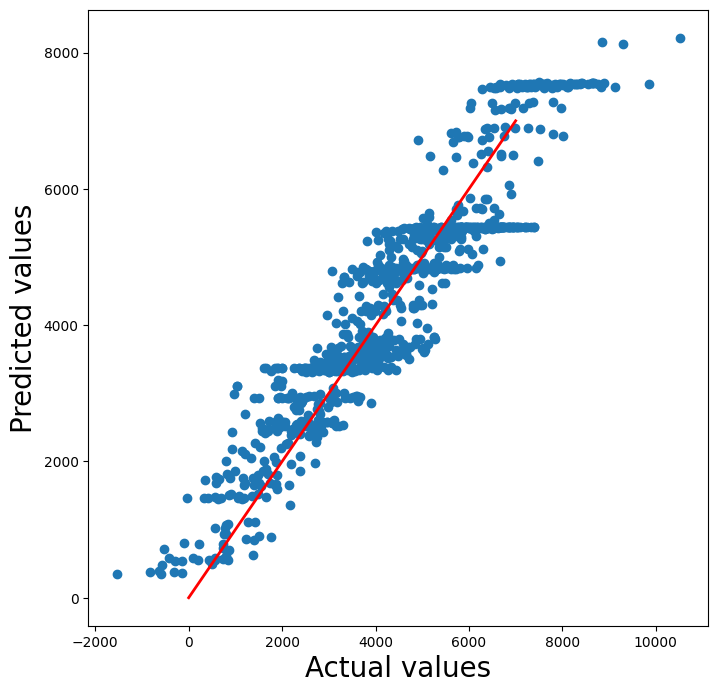

In [6]:
# Model evaluation
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(8, 8))

plt.scatter(y, y_pred)
plt.plot([0, 7000], [0, 7000], color='r', linestyle='-', linewidth=2)

plt.ylabel('Predicted values', size=20)
plt.xlabel('Actual values', size=20)

### Explaining PDPs

* `partial_dependence(...)` computes how the model’s prediction changes as you vary one feature while holding all the other features at their observed values. With `kind='individual'`, this produces **ICE curves** (Individual Conditional Expectation): one curve per row in `x`.

* `rf`: your **fitted** estimator (e.g., a RandomForest). It must already be trained.

* `x`: the dataset (same columns the model expects). For ICE, each row’s **other features stay fixed**; only the chosen feature is varied.

* `['car_age']`: the feature whose effect you’re studying. Because you passed a list with one string, it’s a **1D** partial dependence on the column named `"car_age"`.

* `percentiles=(0, 1)`: the grid of values for `car_age` spans from the **min (0th percentile)** to the **max (100th percentile)** in `x`. (Default is usually `(0.05, 0.95)` to avoid extreme outliers; you’re using the full range.)

* `grid_resolution=100`: build **100 evenly spaced** `car_age` values across that range. Each ICE line will have 100 points.

* `kind='individual'`: return **one prediction curve per sample** (not the average). If `x` has 1000 rows, you’ll get **1000 lines**.

#### What `pdp_lines` contains

`partial_dependence` returns a tuple `(preds, grid_values)`:

* `preds`: for `kind='individual'` and a single output model, has shape **(1, n\_samples, 100)**
  – index 0 is the single target,
  – `n_samples` is the number of rows in `x` (e.g., 1000),
  – `100` is `grid_resolution`.

* `grid_values`: a list with one array for your feature; `grid_values[0]` has length **100** (the actual `car_age` values used on the x-axis).

In [7]:
# Get 1000 individual prediction lines
pdp_lines=partial_dependence(
    rf,
    x,
    ['car_age'],
    percentiles=(0, 1),
    # Each line will have 100 steps from min to max percentile
    grid_resolution=100,
    kind='individual'
)

In [8]:
print(len(pdp_lines['individual'][0]))

1000


In [9]:
# 1 feature, 1000 prediction lines and each line has 100 points
print(np.shape(pdp_lines['individual']))

(1, 1000, 100)


In [10]:
# 1 feature and 100 permuted values for that feature
print(np.shape(pdp_lines['grid_values']))

(1, 100)


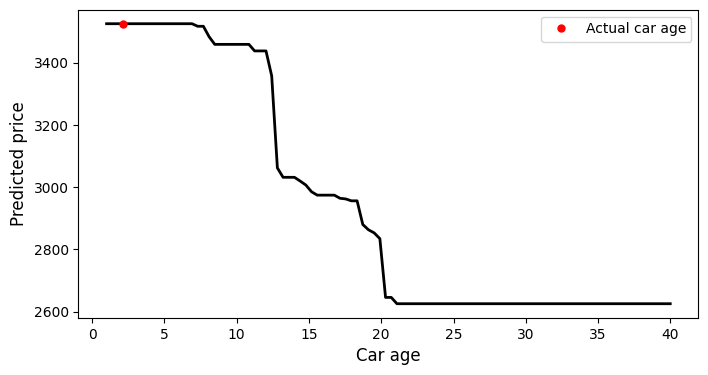

In [11]:
# Plot the first prediction line
plt.figure(figsize=(8, 4))
plt.plot(pdp_lines['grid_values'][0], pdp_lines['individual'][0][0], linewidth=2, color='black')

# Add red dot for actual car age
car_0=data.iloc[0]
plt.plot(car_0['car_age'], y_pred[0], 'ro', markersize=5, label='Actual car age')

plt.ylabel('Predicted price', size=12)
plt.xlabel('Car age', size=12)
plt.legend(loc='upper right')

* `pdp_lines['grid_values'][0]` — the x-values for the plot: an array of the grid of `car_age` values used by the partial dependence function. Expected shape: `(grid_resolution,)` (e.g., `(100,)`).
* `pdp_lines['individual'][0][0]` — the y-values to plot: the ICE curve for the first target (index `0`) and the first sample (index `0`). Expected shape: `(grid_resolution,)`.

  * If `pdp_lines['individual']` has shape `(1, n_samples, grid_resolution)`, then `[0][0]` selects the 0th target (single output) and the first sample, producing a 1-D array of length `grid_resolution`.

#### Expected shapes & indexing summary

* `pdp_lines['grid_values'][0]` → shape `(grid_resolution,)` (e.g., 100).
* `pdp_lines['individual']` → often shape `(1, n_samples, grid_resolution)` for single-output models.

  * `pdp_lines['individual'][0][0]` → the first sample’s ICE, shape `(grid_resolution,)`.
* `y_pred` → shape `(n_samples,)`, so `y_pred[0]` is scalar.

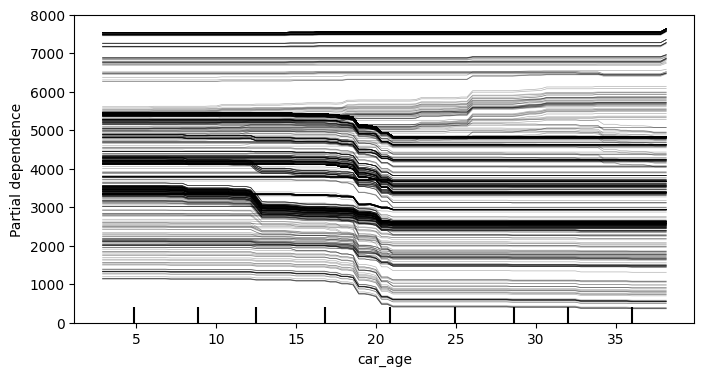

In [12]:
# ICE plot
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    rf,
    x,
    ['car_age'],
    kind='individual',
    ice_lines_kw={'color': 'black'},
    ax=ax
)

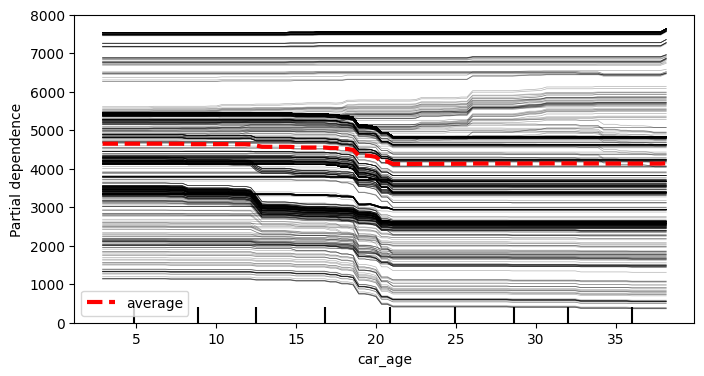

In [13]:
# ICE plot and PDP
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    rf,
    x,
    ['car_age'],
    kind='both',
    ice_lines_kw={'color': 'black'},
    pd_line_kw={'color': 'red', 'lw': 3, 'linestyle': '--'},
    ax=ax
)

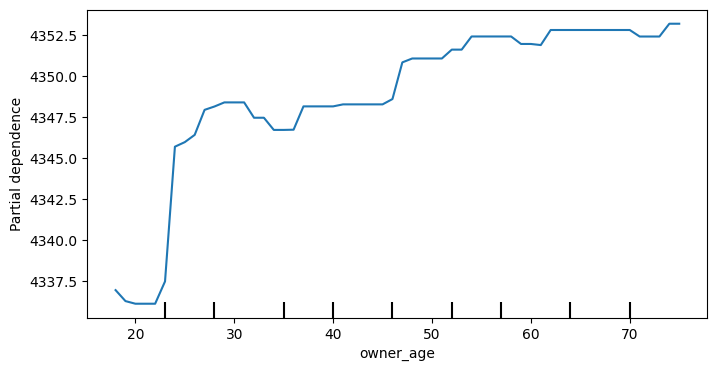

In [14]:
# PDP for owner age
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    rf,
    x,
    ['owner_age'],
    kind='average',
    ax=ax
)

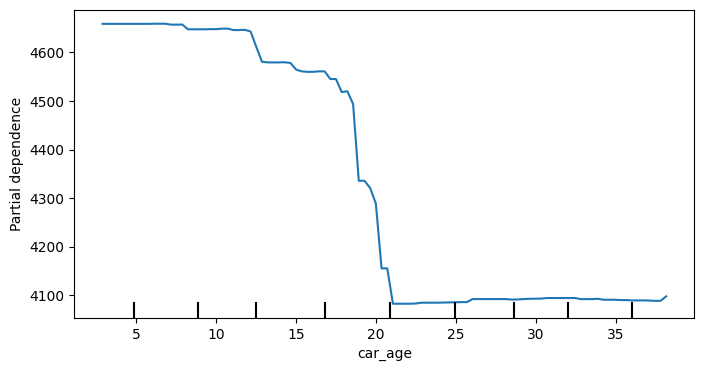

In [15]:
# PDP for car age
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    rf,
    x,
    ['car_age'],
    kind='average',
    ax=ax
)

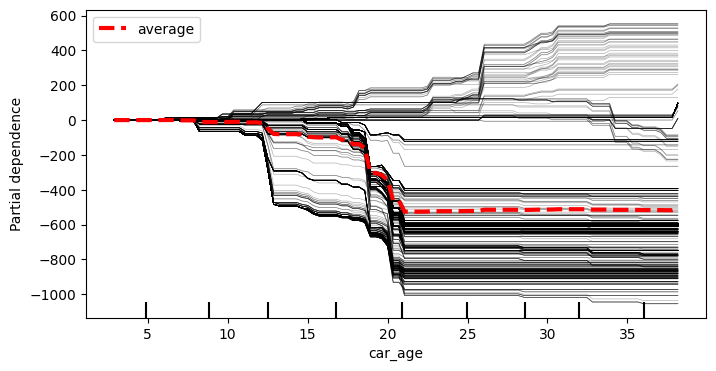

In [16]:
# ICE plot and PDP
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    rf,
    x,
    ['car_age'],
    kind='both',
    ice_lines_kw={'color': 'black'},
    pd_line_kw={'color': 'red', 'lw': 3, 'linestyle': '--'},
    ax=ax,
    centered=True
)

### Custom ICE Plot

In [17]:
pdp_lines=partial_dependence(
    rf,
    x,
    ['car_age'],
    percentiles=(0, 1),
    grid_resolution=100,
    kind='both'
)

# Center the lines
for i in range(1000):
    pdp_start=pdp_lines['individual'][0][i][0]
    pdp_lines['individual'][0][i]=pdp_lines['individual'][0][i]-pdp_start

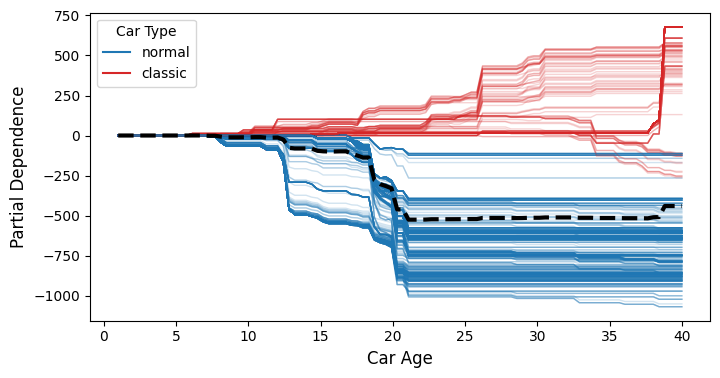

In [18]:
color_feature='car_type'
colors=['tab:blue', 'tab:red']
plt.figure(figsize=(8, 4))

# ICE Plot
for i in range(1000):
    color=colors[x[color_feature].values[i]]
    plt.plot(
        pdp_lines['grid_values'][0],
        pdp_lines['individual'][0][i],
        linewidth=1,
        color=color,
        alpha=0.2
    )

# PDP Line
pdp=pdp_lines['average'][0]-pdp_lines['average'][0][0]
plt.plot(pdp_lines['grid_values'][0], pdp, linewidth=3, color='black', linestyle='--')

plt.ylabel('Partial Dependence', size=12)
plt.xlabel('Car Age', size=12)

# Add custom legend with color for each car type
plt.legend(
    handles=[
        plt.Line2D([0], [0], color=colors[0], label='normal'),
        plt.Line2D([0], [0], color=colors[1], label='classic')
    ],
    title='Car Type'
)

### 2D PDP

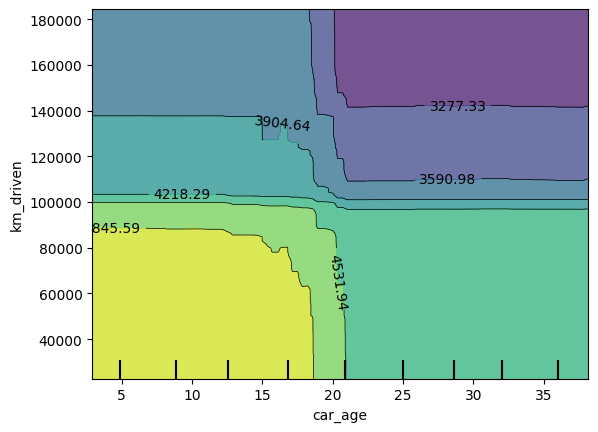

In [19]:
features=[('car_age', 'km_driven')]
PartialDependenceDisplay.from_estimator(rf, x, features=features)

- `Colors` of the plot is determined by the average predicted price for the given feature pair.

- These PDPs are useful for visualizing interactions between features. The chart of 2D PDP shows the possible interaction between the 2 features

### PDP for Categorical features

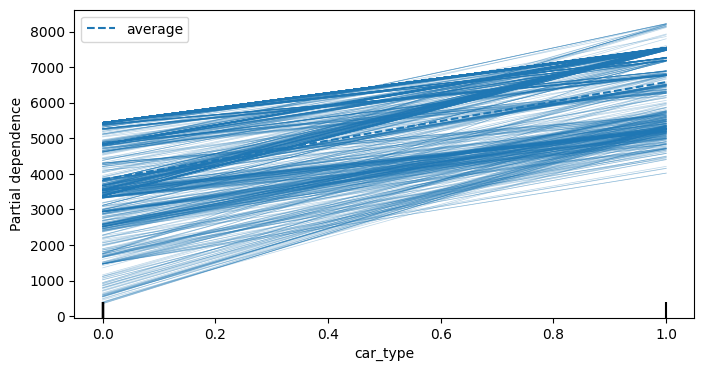

In [20]:
features=['car_type']
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    estimator=rf,
    X=x,
    features=features,
    kind='both',
    ax=ax
)

Text(0.5, 0, 'Car Type')

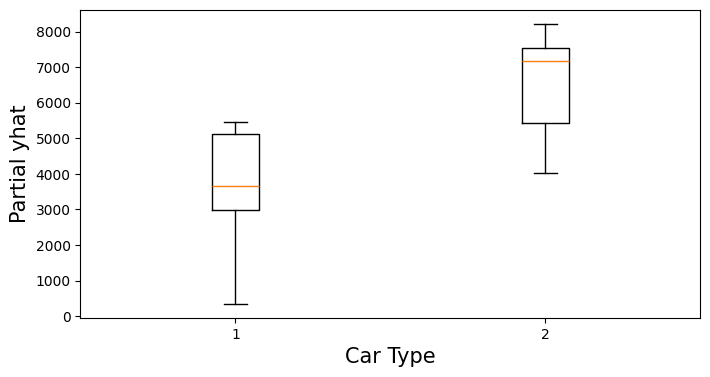

In [22]:
# PDP boxplot for car type
features=['car_type']
pdp_lines=partial_dependence(
    estimator=rf,
    X=x,
    features=features,
    kind='both'
)

# Get the ICE values
ice=pdp_lines['individual'][0]
normal_ice=[i[0] for i in ice]
classic_ice=[i[1] for i in ice]
data=[normal_ice, classic_ice]

# Plot the ICE values
plt.figure(figsize=(8, 4))
labels=['normal', 'classic']
plt.boxplot(data, label=labels)

plt.ylabel('Partial yhat', size=15)
plt.xlabel('Car Type', size=15)

Text(0.5, 0, 'Car Type')

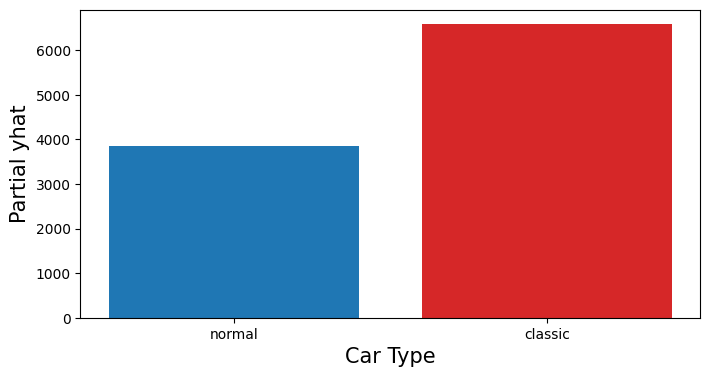

In [27]:
# PDP barchart for car type
features=['car_type']
pdp_lines=partial_dependence(
    estimator=rf,
    X=x,
    features=features,
    kind='both'
)

# Get the ICE values
ice=pdp_lines['individual'][0]
normal_ice=[i[0] for i in ice]
classic_ice=[i[1] for i in ice]

normal_mean=np.mean(normal_ice)
classic_mean=np.mean(classic_ice)
data=[normal_mean, classic_mean]

# Plot the ICE values
plt.figure(figsize=(8, 4))
labels=['normal', 'classic']
plt.bar(labels, data, color=['tab:blue', 'tab:red'])

plt.ylabel('Partial yhat', size=15)
plt.xlabel('Car Type', size=15)

### Binary Target Variable

In [29]:
avg_y=np.mean(y)
y_binary=[1 if y_>=avg_y else 0 for y_ in y]

# Train the model
rfc=RandomForestClassifier(max_depth=4, n_estimators=100, random_state=0)
rfc.fit(x, y_binary)

# Get predictions
y_pred=rfc.predict(x)

print(confusion_matrix(y_binary, y_pred))
accuracy_score(y_binary, y_pred)

[[462  49]
 [ 27 462]]


0.924

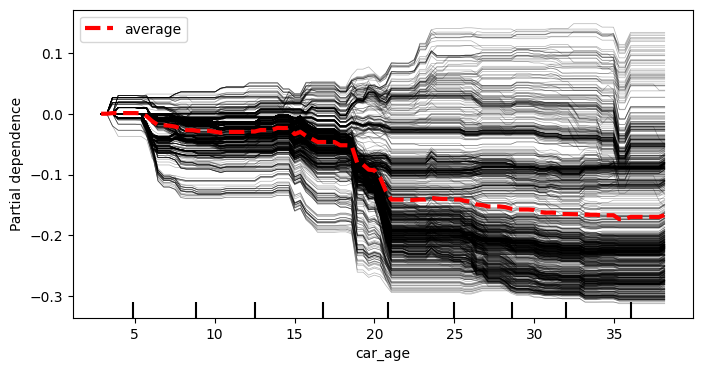

In [31]:
# PDP for binary target variable
features=['car_age']
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    estimator=rfc,
    X=x,
    features=features,
    centered=True,
    kind='both',
    ice_lines_kw={'color': 'black'},
    pd_line_kw={'color': 'red', 'lw': 3, 'linestyle': '--'},
    ax=ax
)